## CREDIT CARD FRAUD PREDICTION

#### Problem Statement
Financial institutions process millions of transactions daily, making it increasingly difficult to accurately distinguish between legitimate and fraudulent activity in real time. Fraudulent transactions are often rare, evolving, and deliberately designed to mimic normal behavior, which makes detection inherently challenging. This creates a dual risk: undetected fraud leads to direct financial losses and regulatory exposure, while excessive false positives result in declined legitimate transactions, poor customer experience, and erosion of trust.

At its core, credit card fraud detection is a highly imbalanced binary classification problem, where fraudulent transactions represent a very small fraction of total activity. Traditional rule-based systems struggle to adapt to dynamic fraud patterns, necessitating data-driven approaches that can learn subtle behavioral signals from transaction data.

The objective of this project is to develop a robust machine learning model capable of identifying fraudulent transactions with high recall (to minimize missed fraud cases) while maintaining acceptable precision (to reduce false alarms). Achieving this balance is critical to ensuring both operational efficiency and customer satisfaction in real-world financial systems.

#### Objectives

* Build a robust fraud detection model
* Handle extreme class imbalance
* Optimize for ROC-AUC and Recall
* Provide explainability using SHAP
* Deploy model for real-time inference
* Design A/B testing strategy

In [1]:
#Importing necessary libraries

import sklearn

import pandas as pd
import numpy as np

#importing libraries for visualization
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#loading the data set
credit = pd.read_csv("C:\\Users\\hp\\OneDrive\\Documents\\Data Science\\Datasets\\creditcard - Copy.csv")

In [3]:
#viewing the first 5 rows
credit.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
#checking the data shape
credit.shape

(284807, 31)

In [5]:
#inspecting the data
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
#checking the descriptive statistics
credit.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
#checking for missing values
credit.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
#checking for unique values
credit.Class.unique()

array([0, 1])

In [9]:
#Checking the class distribution
credit['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### 4. Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Class Distribution')

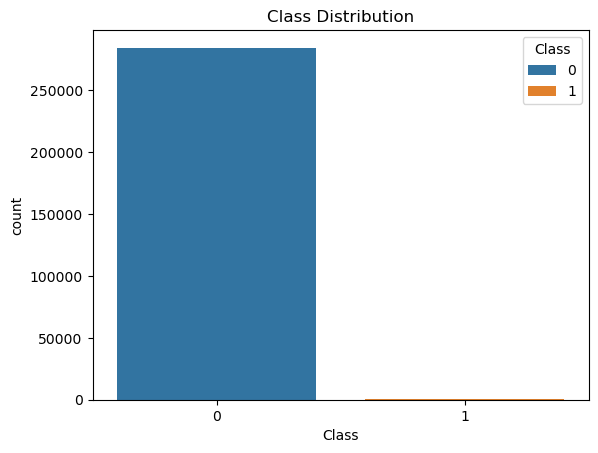

In [10]:
### Fraud vs Non-Fraud
sns.countplot(x='Class', data=credit, hue="Class")
plt.title('Class Distribution')


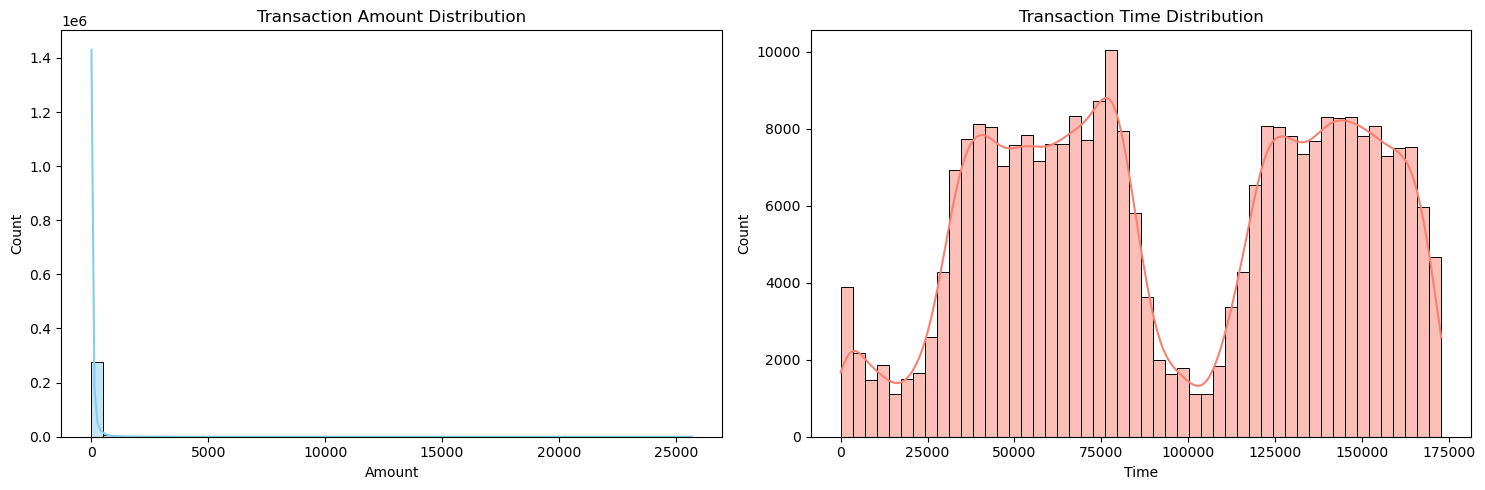

In [11]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Transaction Amount
sns.histplot(credit['Amount'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Transaction Amount Distribution')

# Plot 2: Transaction Time
sns.histplot(credit['Time'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Transaction Time Distribution')

plt.tight_layout()
plt.show()

In [12]:
#Selecting features to plot
feat_to_plot = credit[[ 'Time', 'Amount']]

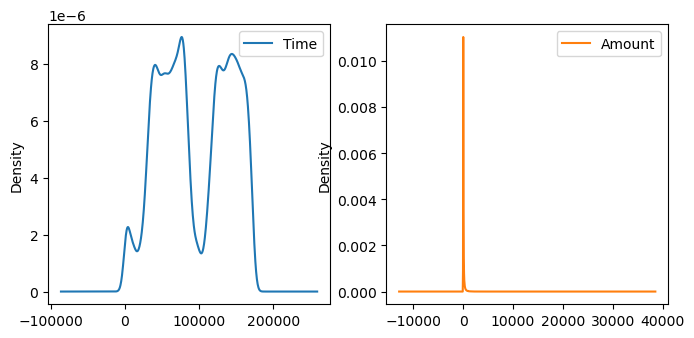

In [13]:
#Plotting density plots of selected variables
feat_to_plot.plot(kind='density', 
                   subplots=True, 
                   layout=(2, 2), 
                   sharex=False, 
                   figsize=(8, 8))

plt.show()

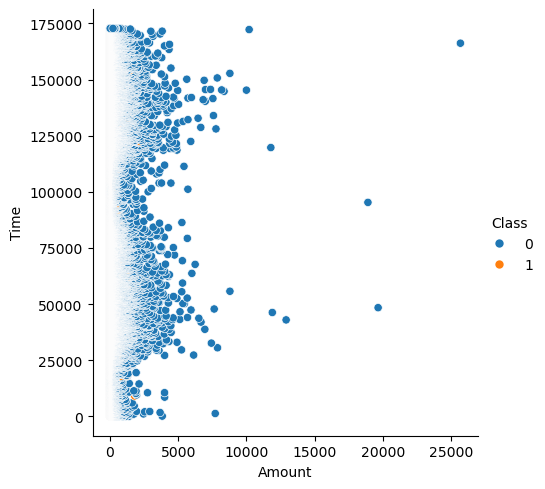

In [14]:
#visualization the target variable using a relplot
sns.relplot(data=credit, x="Amount", y="Time", hue="Class")

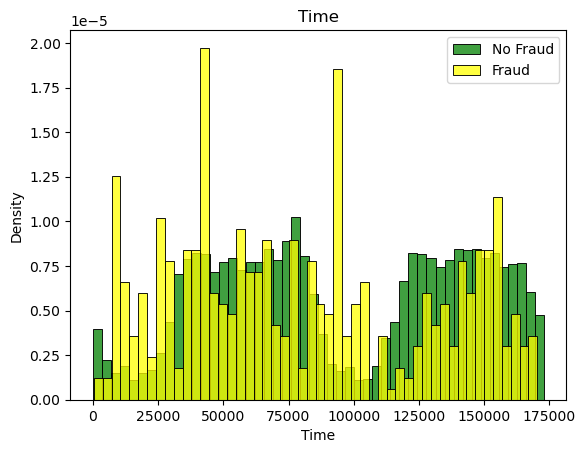

In [15]:
#visualizing the distribution of the target variable against Time
ax = plt.subplot()
sns.histplot(credit['Time'][credit.Class==0], bins=50, color="green",stat="density")
sns.histplot(credit['Time'][credit.Class==1], bins=50, color="yellow",stat="density")
plt.legend(["No Fraud", "Fraud"])
ax.set_title('Time')
             
plt.show()

Time         Axes(0.125,0.53;0.352273x0.35)
Amount    Axes(0.547727,0.53;0.352273x0.35)
dtype: object

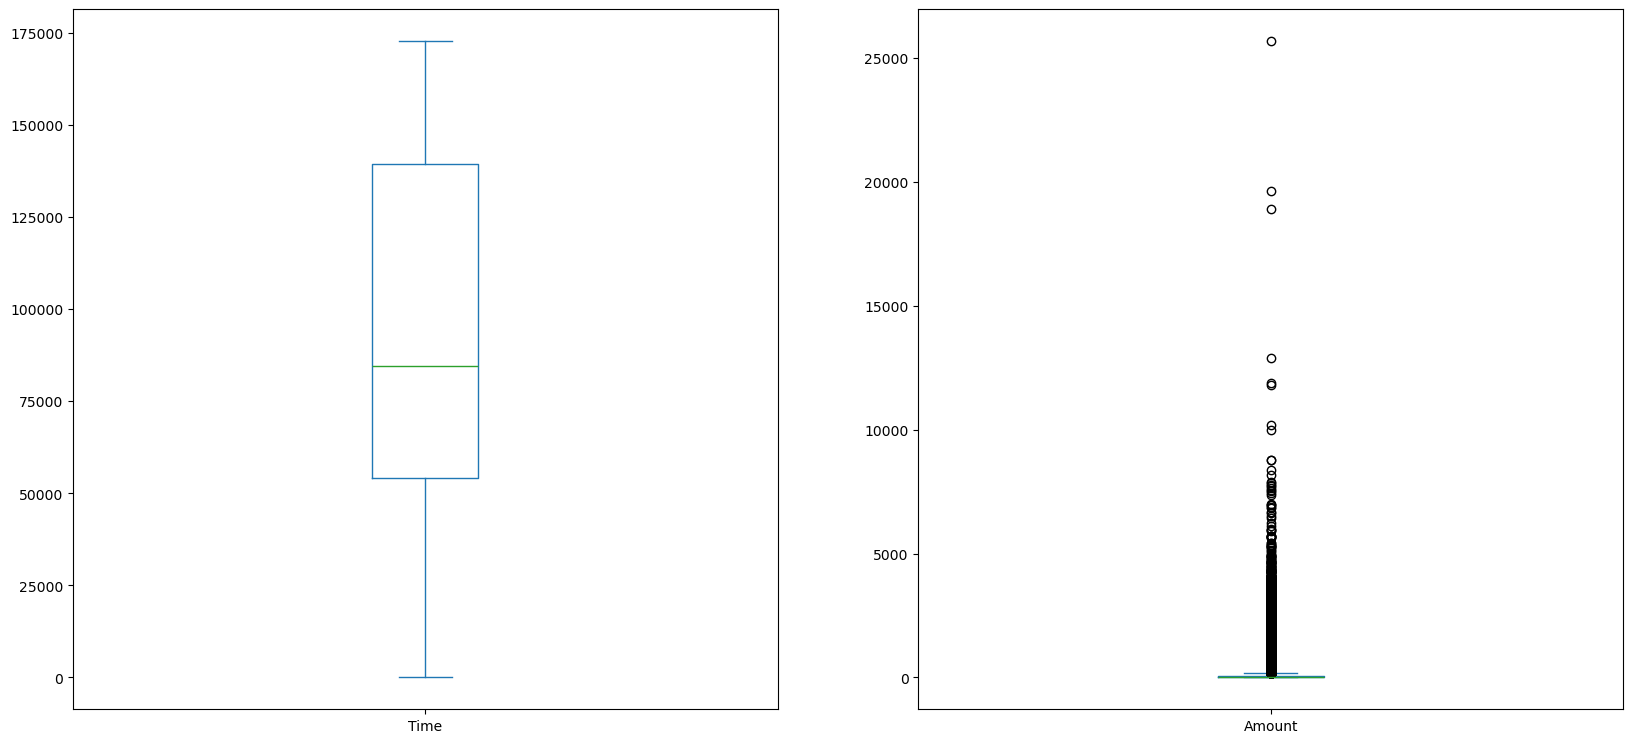

In [16]:
#Plotting box plots to visualize outliers
feat_to_plot.plot(kind='box', 
                   subplots=True, 
                   layout=(2, 2), 
                   sharex=False, 
                   figsize=(20, 20))

#### Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split
#assigning values
X = credit.drop('Class', axis=1)
y = credit['Class']

# split into 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# describes info about train and test set
print("X_train size: ", X_train.shape)
print("y_train size: ", y_train.shape)
print("X_test size: ", X_test.shape)
print("y_test size: ", y_test.shape)

X_train size:  (199364, 30)
y_train size:  (199364,)
X_test size:  (85443, 30)
y_test size:  (85443,)


#### Modeling Pipeline

In [18]:
# Define Models
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [19]:
# Defining Models
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
    )
}

In [20]:
# Pipeline Builder (Scaling + SMOTE + Model)
def build_pipeline(model):
    return Pipeline([
        ('scaler', RobustScaler()),
        ('smote', SMOTEENN(random_state=42)),
        ('model', model)
    ])


#### Train & Evaluate Models

In [21]:
from sklearn.metrics import roc_auc_score, f1_score

# Model Training & Selection
results = {}

best_score = 0
best_model = None
best_model_name = None

for name, model in models.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)

    roc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, pred)

    results[name] = {
        "ROC-AUC": roc,
        "F1 (0.5 thresh)": f1
    }

    if roc > best_score:
        best_score = roc
        best_model = pipe
        best_model_name = name

#### Model Comparison Table

In [22]:
# Model Comparison Table
results_df = pd.DataFrame(results).T.sort_values(by="ROC-AUC", ascending=False)

print("\nModel Comparison:")
print(results_df)

print(f"\nBest Model: {best_model_name} | ROC-AUC: {best_score:.4f}")


Model Comparison:
                      ROC-AUC  F1 (0.5 thresh)
Logistic Regression  0.965714         0.114718
XGBoost              0.964744         0.634021
Random Forest        0.957952         0.798635

Best Model: Logistic Regression | ROC-AUC: 0.9657


In [23]:
# Threshold Optimization (F1)
proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0, 1, 100)
f1_scores = []

for t in thresholds:
    preds = (proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_thresh = thresholds[np.argmax(f1_scores)]

print(f"\nOptimal Threshold: {best_thresh:.4f}")


Optimal Threshold: 1.0000


In [25]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Final Evaluation
final_preds = (proba >= best_thresh).astype(int)

print("\nFinal Model Performance:")
print(classification_report(y_test, final_preds))

print("Final F1:", f1_score(y_test, final_preds))
print("Final ROC-AUC:", roc_auc_score(y_test, proba))


Final Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.62      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443

Final F1: 0.7244094488188977
Final ROC-AUC: 0.9657139054759079


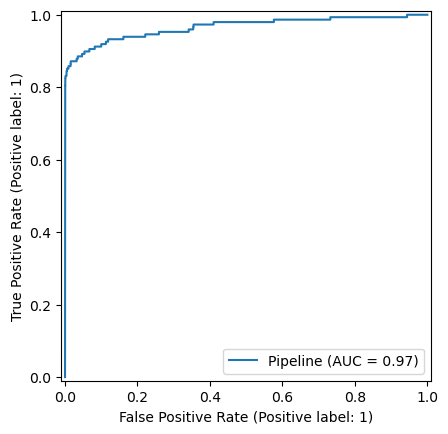

In [26]:
## ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

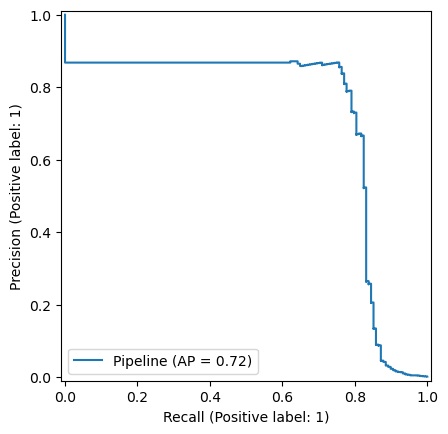

In [27]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)

#### Feature Importance

In [31]:
# no feature importance if best model is logistic regression

model = best_model.named_steps['model']

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
    
    feat_imp.head(10).plot(kind='barh')
else:
    print("Feature importance not available for this model.")

Feature importance not available for this model.


#### Explainability (SHAP)

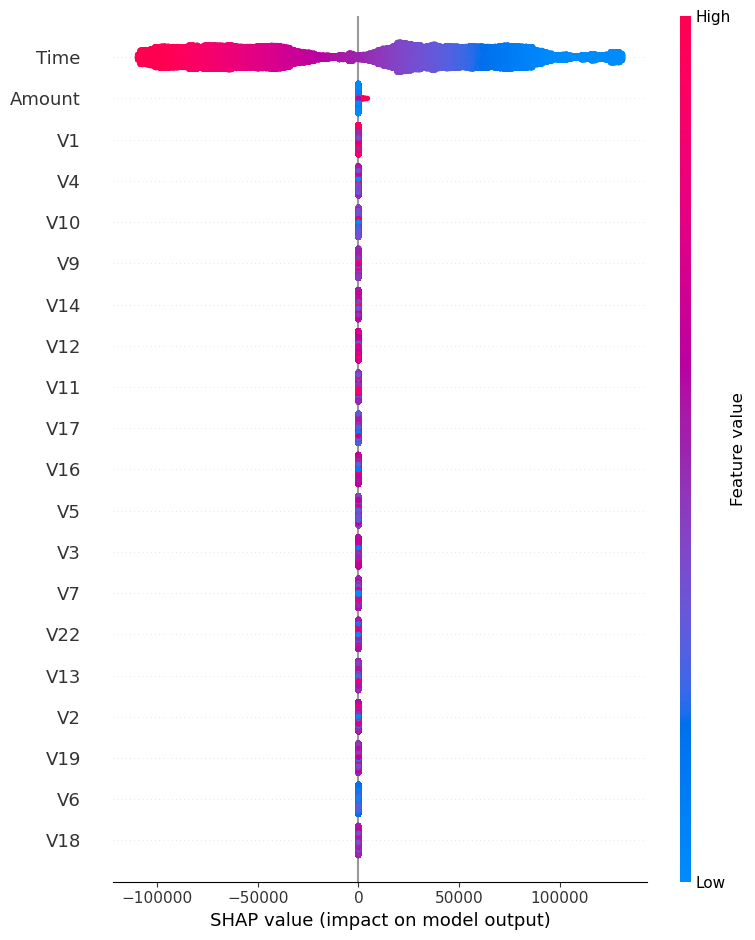

In [32]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

#### Model Export

In [33]:
import joblib
joblib.dump(pipe, 'fraud_model.pkl')

['fraud_model.pkl']

#### Deployment (FastAPI)

In [36]:
from fastapi import FastAPI

app = FastAPI()
model = joblib.load('fraud_model.pkl')

@app.post('/predict')
def predict(data: dict):
    df = pd.DataFrame([data])
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]
    return {'prediction': int(pred), 'probability': float(prob)}

### A/B Testing Strategy

#### Goal

Compare new fraud model vs existing baseline

##### Design

* Split traffic: 50% control, 50% treatment
* Metrics:

  * Fraud detection rate (Recall)
  * False positive rate
  * Revenue impact

##### Implementation

In [37]:
import random

def route_user(user_id):
    return 'A' if hash(user_id) % 2 == 0 else 'B'

#### Key Takeaways

* Proper handling of imbalance is critical
* Pipelines prevent leakage
* Explainability builds trust
* Deployment requires latency awareness
